# Step 54c.3 — Null-calibration + regime-feature screen

For `FLAGSHIP_6BCEH_SHORT_VWAP_RSI60` (locked SL=1.5/TP=4.5/RSI>60). Screening two
candidate market-wide regime features — **NIFTY trend (10-day)** and **basket
dispersion** — against this variant's own trade outcomes, per the design spec in
`54_6bceh_short_vwap_rsi_baseline.md` §4.

- **Unit of analysis: per trading day, not per trade.** Multiple trades can share one
  day's feature value (same day, different stocks) — correlating raw per-trade zpnl
  against a daily feature risks pseudo-replication. Aggregate first.
- **Target A (leads): daily net zpnl** — sum of that day's trades.
- **Target B (fast binary screen): daily net-profitable-day flag** — `daily_zpnl > 0`,
  NOT a win-rate fraction (that would itself be continuous, not binary).
- **Method: Pearson r as a screening/diagnostic statistic, not a fitted regression** —
  no `y_hat`, no coefficients deployed live. `r` only decides whether a feature is
  worth pursuing as a simple threshold gate.
- **Null-calibration order: individual first (primary), combined second (secondary
  robustness check)** — each feature's own dedicated noise ceiling is the direct,
  transparent answer to "is THIS specific r real"; the combined (max-of-2,
  multiple-testing-corrected) ceiling is a stricter follow-up check, relevant because
  the practical decision is "does at least one of these two pass."


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
plt.style.use('dark_background')

np.random.seed(42)  # reproducible null-shuffle
N_SHUFFLES = 5000
FEATURES = ['nifty_trend_10d', 'dispersion']

trades = pd.read_csv('54c_trade_log_with_features.csv', parse_dates=['signal_dt'])
trades['date'] = trades['signal_dt'].dt.date
print(f'{len(trades):,} trades loaded')
trades[['date', 'zpnl', 'nifty_trend_10d', 'dispersion']].head()


14,270 trades loaded


,date,zpnl,nifty_trend_10d,dispersion
0,2015-02-02,-0.1925,NaN,NaN
1,2015-02-02,11.4757,NaN,NaN
2,2015-02-02,-1.4488,NaN,NaN
3,2015-02-02,-1.6896,NaN,NaN
4,2015-02-02,-1.0694,NaN,NaN


## 1. Aggregate to daily level (one row per trading day)

In [2]:
daily = trades.groupby('date').agg(
    daily_zpnl=('zpnl', 'sum'),
    n_trades=('zpnl', 'size'),
    nifty_trend_10d=('nifty_trend_10d', 'first'),   # constant within a day, by construction
    dispersion=('dispersion', 'first'),
).reset_index()

# drop days where either feature is NaN (warmup period at the very start of history)
daily = daily.dropna(subset=['nifty_trend_10d', 'dispersion']).reset_index(drop=True)

daily['profitable_day'] = (daily['daily_zpnl'] > 0).astype(int)  # TRUE binary flag, not a win-rate

print(f'{len(daily):,} trading days retained (after dropping NaN-feature warmup days)')
print(f'profitable_day rate: {daily.profitable_day.mean():.1%}')
daily.describe()


2,488 trading days retained (after dropping NaN-feature warmup days)
profitable_day rate: 40.9%


,daily_zpnl,n_trades,nifty_trend_10d,dispersion,profitable_day
count,2488.000000,2488.000000,2488.000000,2488.000000,2488.000000
mean,-0.998803,5.525723,0.513334,1.641742,0.408762
std,16.702023,4.448352,3.029277,0.708210,0.491704
min,-142.276900,1.000000,-30.749492,0.115560,0.000000
25%,-6.508975,2.000000,-1.184625,1.226964,0.000000
50%,-1.168350,4.000000,0.648063,1.500851,0.000000
75%,3.698075,8.000000,2.291088,1.894721,1.000000
max,150.460200,31.000000,16.803507,12.076059,1.000000


## 2. Individual null-calibration (primary) — one dedicated noise ceiling per feature

For each feature, shuffle the target across days ~5,000 times, correlate against
*that one feature only* each round. Answers, per feature, per target: "if there's
truly no relationship, how extreme could r get by chance alone?" 

In [3]:
def individual_null(target_col, feature_col, n_shuffles=N_SHUFFLES):
    y = daily[target_col].values.astype(float)
    x = daily[feature_col].values
    null_r = np.empty(n_shuffles)
    for i in range(n_shuffles):
        null_r[i] = np.corrcoef(x, np.random.permutation(y))[0, 1]
    return null_r

individual_null_dist = {}
for target in ['daily_zpnl', 'profitable_day']:
    for f in FEATURES:
        individual_null_dist[(target, f)] = individual_null(target, f)

print('Individual ceilings (per feature, per target):')
for (target, f), nulls in individual_null_dist.items():
    c95 = np.percentile(np.abs(nulls), 95)
    c99 = np.percentile(np.abs(nulls), 99)
    print(f'  {target:16s} {f:16s} ceil95={c95:.4f}  ceil99={c99:.4f}')


Individual ceilings (per feature, per target):
  daily_zpnl       nifty_trend_10d  ceil95=0.0392  ceil99=0.0514
  daily_zpnl       dispersion       ceil95=0.0396  ceil99=0.0524
  profitable_day   nifty_trend_10d  ceil95=0.0396  ceil99=0.0513
  profitable_day   dispersion       ceil95=0.0385  ceil99=0.0483


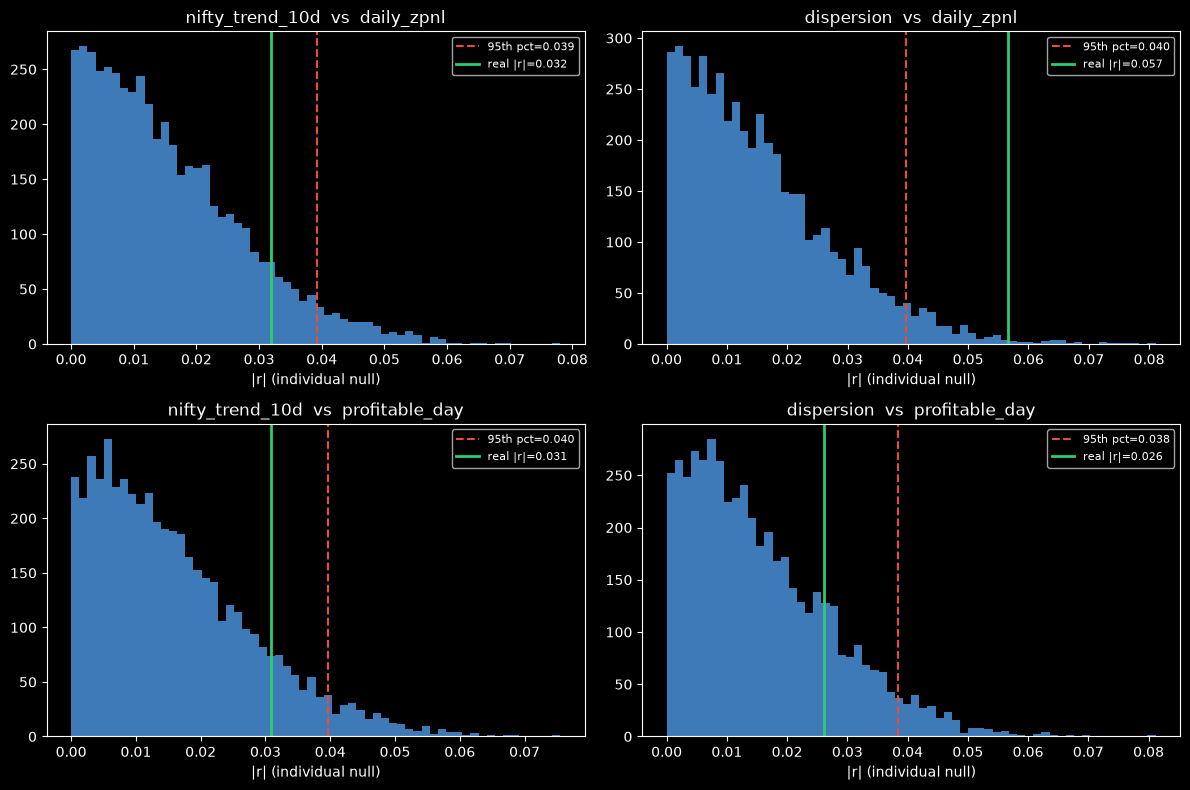

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for row, target in enumerate(['daily_zpnl', 'profitable_day']):
    for col, f in enumerate(FEATURES):
        nulls = individual_null_dist[(target, f)]
        real_r = np.corrcoef(daily[f].values, daily[target].values)[0, 1]
        ceil95 = np.percentile(np.abs(nulls), 95)
        ax = axes[row, col]
        ax.hist(np.abs(nulls), bins=60, color='#4a90d9', alpha=0.85)
        ax.axvline(ceil95, color='#e74c3c', linestyle='--', label=f'95th pct={ceil95:.3f}')
        ax.axvline(abs(real_r), color='#2ecc71', linewidth=2, label=f'real |r|={abs(real_r):.3f}')
        ax.set_title(f'{f}  vs  {target}')
        ax.set_xlabel('|r| (individual null)'); ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


### 2b. Individual null-calibration — circular-shift (the correct primary)

The iid shuffle above destroys the target's own day-to-day structure entirely.
`dispersion` is itself autocorrelated (acf1=0.417 — real vol/dispersion clustering,
not noise), so a persistent feature can spuriously correlate more easily with an
iid-shuffled (memoryless) target than a fair "two realistic-but-unrelated series"
comparison would suggest. Circular shift fixes this: rotate the real target series
by every possible offset (n-1 distinct rotations, enumerated exhaustively — no
sampling needed, unlike iid's N! space) — this preserves the target's own real
structure and breaks only its date-alignment with the feature. **This is the
corrected primary null going forward**; the iid histograms above are kept only as
a before/after comparison, not as the trusted ceiling.

In [5]:
def individual_null_circular(target_col, feature_col):
    y = daily[target_col].values.astype(float)
    x = daily[feature_col].values
    n = len(y)
    null_r = np.empty(n - 1)
    for shift in range(1, n):
        null_r[shift - 1] = np.corrcoef(x, np.roll(y, shift))[0, 1]
    return null_r

individual_null_circ = {}
for target in ['daily_zpnl', 'profitable_day']:
    for f in FEATURES:
        individual_null_circ[(target, f)] = individual_null_circular(target, f)

print('Individual ceilings, CIRCULAR-SHIFT (exhaustive, n-1 rotations):')
for (target, f), nulls in individual_null_circ.items():
    c95 = np.percentile(np.abs(nulls), 95)
    c99 = np.percentile(np.abs(nulls), 99)
    print(f'  {target:16s} {f:16s} ceil95={c95:.4f}  ceil99={c99:.4f}  (n={len(nulls)+1} rotations)')


Individual ceilings, CIRCULAR-SHIFT (exhaustive, n-1 rotations):
  daily_zpnl       nifty_trend_10d  ceil95=0.0449  ceil99=0.0612  (n=2488 rotations)
  daily_zpnl       dispersion       ceil95=0.0458  ceil99=0.0612  (n=2488 rotations)
  profitable_day   nifty_trend_10d  ceil95=0.0422  ceil99=0.0536  (n=2488 rotations)
  profitable_day   dispersion       ceil95=0.0448  ceil99=0.0600  (n=2488 rotations)


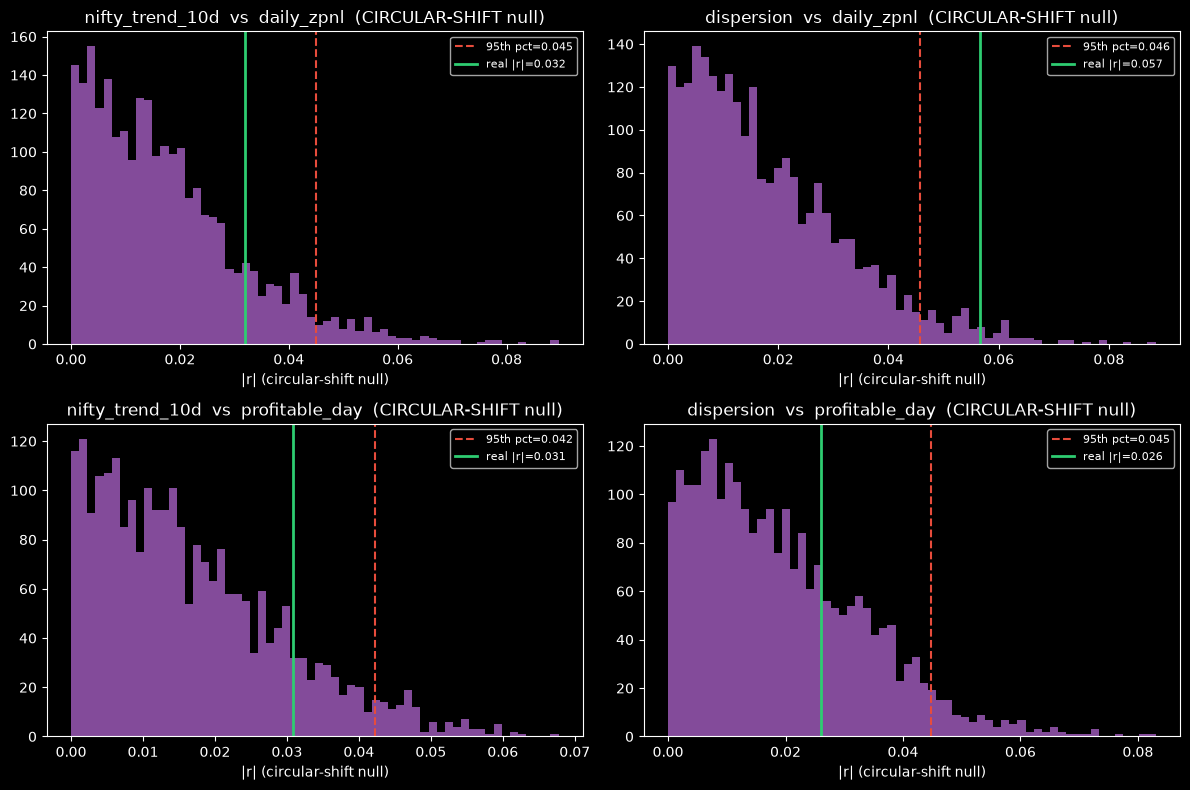

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for row, target in enumerate(['daily_zpnl', 'profitable_day']):
    for col, f in enumerate(FEATURES):
        nulls = individual_null_circ[(target, f)]
        real_r = np.corrcoef(daily[f].values, daily[target].values)[0, 1]
        ceil95 = np.percentile(np.abs(nulls), 95)
        ax = axes[row, col]
        ax.hist(np.abs(nulls), bins=60, color='#9b59b6', alpha=0.85)
        ax.axvline(ceil95, color='#e74c3c', linestyle='--', label=f'95th pct={ceil95:.3f}')
        ax.axvline(abs(real_r), color='#2ecc71', linewidth=2, label=f'real |r|={abs(real_r):.3f}')
        ax.set_title(f'{f}  vs  {target}  (CIRCULAR-SHIFT null)')
        ax.set_xlabel('|r| (circular-shift null)'); ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 3. Combined null-calibration (secondary robustness check) — max-of-2, multiple-testing-corrected

One shared ceiling per target, built from the *max* |r| across both features each
shuffle round — the stricter bar relevant because the actual decision is "does at
least one of the two candidates pass." A result should ideally survive both this and
the individual check above, not just one.

In [7]:
def combined_null(target_col, n_shuffles=N_SHUFFLES):
    y = daily[target_col].values.astype(float)
    max_abs_r = np.empty(n_shuffles)
    for i in range(n_shuffles):
        y_shuffled = np.random.permutation(y)
        rs = [abs(np.corrcoef(daily[f].values, y_shuffled)[0, 1]) for f in FEATURES]
        max_abs_r[i] = max(rs)
    return max_abs_r

combined_null_dist = {t: combined_null(t) for t in ['daily_zpnl', 'profitable_day']}

print('Combined (max-of-2) ceilings:')
for target, nulls in combined_null_dist.items():
    c95 = np.percentile(nulls, 95)
    c99 = np.percentile(nulls, 99)
    print(f'  {target:16s} ceil95={c95:.4f}  ceil99={c99:.4f}')


Combined (max-of-2) ceilings:
  daily_zpnl       ceil95=0.0451  ceil99=0.0587
  profitable_day   ceil95=0.0435  ceil99=0.0552


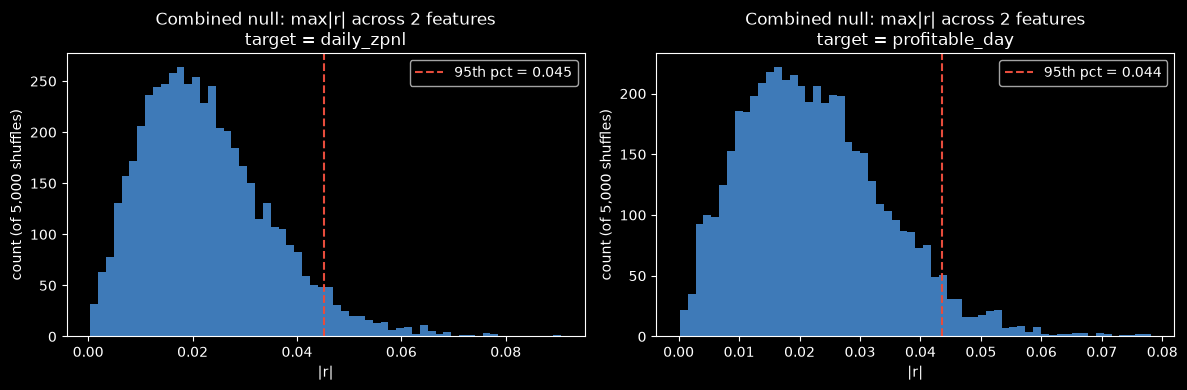

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, target in zip(axes, ['daily_zpnl', 'profitable_day']):
    nulls = combined_null_dist[target]
    ceil95 = np.percentile(nulls, 95)
    ax.hist(nulls, bins=60, color='#4a90d9', alpha=0.85)
    ax.axvline(ceil95, color='#e74c3c', linestyle='--', label=f'95th pct = {ceil95:.3f}')
    ax.set_title(f'Combined null: max|r| across 2 features\ntarget = {target}')
    ax.set_xlabel('|r|'); ax.set_ylabel('count (of 5,000 shuffles)')
    ax.legend()
plt.tight_layout()
plt.show()


### 3b. Combined null-calibration — circular-shift, max-of-2

Same correction as 2b, applied to the combined (max-of-2) ceiling.

In [9]:
def combined_null_circular(target_col, features=FEATURES):
    y = daily[target_col].values.astype(float)
    n = len(y)
    max_abs_r = np.empty(n - 1)
    for shift in range(1, n):
        y_shifted = np.roll(y, shift)
        rs = [abs(np.corrcoef(daily[f].values, y_shifted)[0, 1]) for f in features]
        max_abs_r[shift - 1] = max(rs)
    return max_abs_r

combined_null_circ = {t: combined_null_circular(t) for t in ['daily_zpnl', 'profitable_day']}

print('Combined (max-of-2) ceilings, CIRCULAR-SHIFT:')
for target, nulls in combined_null_circ.items():
    c95, c99 = np.percentile(nulls, [95, 99])
    print(f'  {target:16s} ceil95={c95:.4f}  ceil99={c99:.4f}')


Combined (max-of-2) ceilings, CIRCULAR-SHIFT:
  daily_zpnl       ceil95=0.0535  ceil99=0.0670
  profitable_day   ceil95=0.0485  ceil99=0.0616


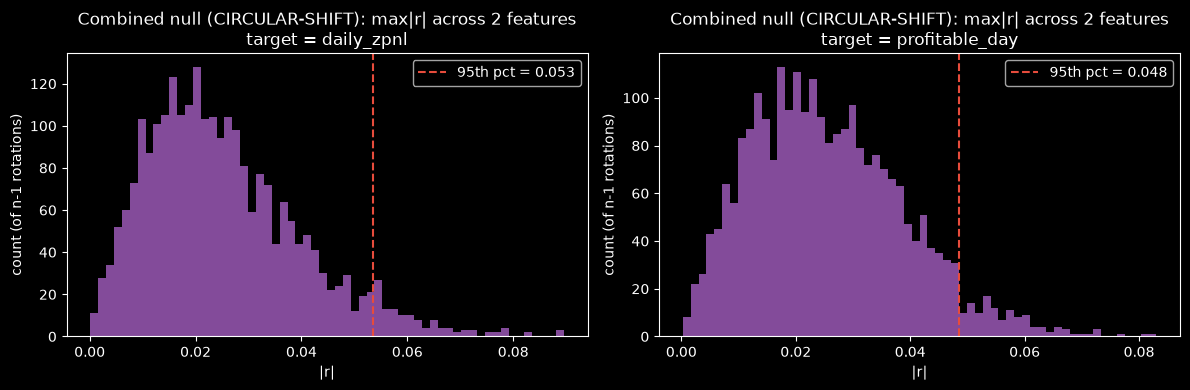

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, target in zip(axes, ['daily_zpnl', 'profitable_day']):
    nulls = combined_null_circ[target]
    ceil95 = np.percentile(nulls, 95)
    ax.hist(nulls, bins=60, color='#9b59b6', alpha=0.85)
    ax.axvline(ceil95, color='#e74c3c', linestyle='--', label=f'95th pct = {ceil95:.3f}')
    ax.set_title(f'Combined null (CIRCULAR-SHIFT): max|r| across 2 features\ntarget = {target}')
    ax.set_xlabel('|r|'); ax.set_ylabel('count (of n-1 rotations)')
    ax.legend()
plt.tight_layout()
plt.show()


### 3c. Widened scope — max-of-N (was this pair chosen after implicitly comparing
all available candidates? Correcting for that possibility)

The max-of-2 ceiling above only accounts for 2 "looks." All candidate features built so
far in `54c_regime_features.py` (+ `54c_add_volume_vix.py`) were available to be picked
from — to be safe, this widens the combined-null correction to max-of-N (N = however
many candidates actually exist, not a fixed number — currently 12), both iid and
circular-shift. **This N grows every time a new candidate feature gets built** (it was
10, now 12 with `volume_surge` + `india_vix_level` added 2026-09-17) — there is no
target/fixed cap on the count itself.

In [11]:
CANDIDATE_FEATURES = ['gap_pct', 'nifty_trend_5d', 'nifty_trend_10d', 'realized_vol_nifty_10d',
                       'dist_from_ma50_nifty', 'basket_trend_5d', 'basket_trend_10d', 'dispersion',
                       'breadth', 'realized_vol_basket_10d', 'volume_surge', 'india_vix_level']
N_CAND = len(CANDIDATE_FEATURES)  # 12 as of 2026-09-17 (volume_surge + india_vix_level added)

daily_all = trades.groupby('date').agg(
    daily_zpnl=('zpnl', 'sum'),
    **{f: (f, 'first') for f in CANDIDATE_FEATURES}
).reset_index()
daily_all['profitable_day'] = (daily_all['daily_zpnl'] > 0).astype(int)
daily_all = daily_all.dropna(subset=CANDIDATE_FEATURES + ['daily_zpnl']).reset_index(drop=True)
print(f'{len(daily_all):,} days retained (all {N_CAND} candidate features + target non-null)')

def _pearson_cols(X, y):
    Xc = X - X.mean(axis=0); yc = y - y.mean()
    num = (Xc * yc[:, None]).sum(axis=0)
    den = np.sqrt((Xc**2).sum(axis=0) * (yc**2).sum())
    return num / den

Xall = daily_all[CANDIDATE_FEATURES].values

def combined_null_N_iid(target_col, n_shuffles=N_SHUFFLES):
    y = daily_all[target_col].values.astype(float)
    max_abs_r = np.empty(n_shuffles)
    y_shuf = y.copy()
    for i in range(n_shuffles):
        np.random.shuffle(y_shuf)
        max_abs_r[i] = np.abs(_pearson_cols(Xall, y_shuf)).max()
    return max_abs_r

def combined_null_N_circular(target_col):
    y = daily_all[target_col].values.astype(float)
    n = len(y)
    max_abs_r = np.empty(n - 1)
    for shift in range(1, n):
        max_abs_r[shift - 1] = np.abs(_pearson_cols(Xall, np.roll(y, shift))).max()
    return max_abs_r

combined_null_N_iid_dist = {t: combined_null_N_iid(t) for t in ['daily_zpnl', 'profitable_day']}
combined_null_N_circ_dist = {t: combined_null_N_circular(t) for t in ['daily_zpnl', 'profitable_day']}

print()
print('Real r, every candidate, sorted by |r| (target=daily_zpnl):')
real_r_zpnl = _pearson_cols(Xall, daily_all['daily_zpnl'].values.astype(float))
for f, r in sorted(zip(CANDIDATE_FEATURES, real_r_zpnl), key=lambda t: -abs(t[1])):
    print(f'  {f:>25}: {r:+.4f}')

print()
for t in ['daily_zpnl', 'profitable_day']:
    real_rN = _pearson_cols(Xall, daily_all[t].values.astype(float))
    best_i = np.argmax(np.abs(real_rN))
    print(f'--- target={t}  best-of-{N_CAND} = {CANDIDATE_FEATURES[best_i]} (r={real_rN[best_i]:+.4f}) ---')
    for label, nulls in [('iid', combined_null_N_iid_dist[t]), ('circular', combined_null_N_circ_dist[t])]:
        c95, c99 = np.percentile(nulls, [95, 99])
        emp_p = (nulls >= abs(real_rN[best_i])).mean()
        disp_r = real_rN[CANDIDATE_FEATURES.index('dispersion')]
        print(f'  {label:9s} max-of-{N_CAND}: ceil95={c95:.4f} ceil99={c99:.4f} emp_p(best-of-{N_CAND})={emp_p:.4f}'
              f'  | dispersion alone clears95={abs(disp_r)>c95}')


2,453 days retained (all 12 candidate features + target non-null)



Real r, every candidate, sorted by |r| (target=daily_zpnl):
                    gap_pct: -0.0625
                 dispersion: +0.0575
            india_vix_level: +0.0519
               volume_surge: -0.0506
            nifty_trend_10d: +0.0310
                    breadth: -0.0212
    realized_vol_basket_10d: +0.0203
     realized_vol_nifty_10d: +0.0193
           basket_trend_10d: +0.0187
            basket_trend_5d: +0.0147
       dist_from_ma50_nifty: +0.0118
             nifty_trend_5d: +0.0107

--- target=daily_zpnl  best-of-12 = gap_pct (r=-0.0625) ---
  iid       max-of-12: ceil95=0.0573 ceil99=0.0690 emp_p(best-of-12)=0.0238  | dispersion alone clears95=True
  circular  max-of-12: ceil95=0.0629 ceil99=0.0812 emp_p(best-of-12)=0.0534  | dispersion alone clears95=False
--- target=profitable_day  best-of-12 = volume_surge (r=-0.0486) ---
  iid       max-of-12: ceil95=0.0565 ceil99=0.0654 emp_p(best-of-12)=0.1364  | dispersion alone clears95=False
  circular  max-of-12: ceil95=0.0

## 4. The real screen — actual r for each (feature, target) pair, both ceilings shown

In [12]:
results = []
for target_col in ['daily_zpnl', 'profitable_day']:
    for f in FEATURES:
        r_real = np.corrcoef(daily[f].values, daily[target_col].values)[0, 1]

        # iid
        ind_nulls = individual_null_dist[(target_col, f)]
        ind_ceil95 = np.percentile(np.abs(ind_nulls), 95)
        ind_ceil99 = np.percentile(np.abs(ind_nulls), 99)
        emp_p_individual = (np.abs(ind_nulls) >= abs(r_real)).mean()

        comb_nulls = combined_null_dist[target_col]
        comb_ceil95 = np.percentile(comb_nulls, 95)
        comb_ceil99 = np.percentile(comb_nulls, 99)
        emp_p_combined = (comb_nulls >= abs(r_real)).mean()

        # circular-shift (correct primary)
        ind_nulls_c = individual_null_circ[(target_col, f)]
        ind_ceil95_c = np.percentile(np.abs(ind_nulls_c), 95)
        ind_ceil99_c = np.percentile(np.abs(ind_nulls_c), 99)
        emp_p_individual_c = (np.abs(ind_nulls_c) >= abs(r_real)).mean()

        comb_nulls_c = combined_null_circ[target_col]
        comb_ceil95_c = np.percentile(comb_nulls_c, 95)
        comb_ceil99_c = np.percentile(comb_nulls_c, 99)
        emp_p_combined_c = (comb_nulls_c >= abs(r_real)).mean()

        n = len(daily)
        t_stat = r_real * np.sqrt((n - 2) / (1 - r_real**2))
        textbook_p = 2 * stats.t.sf(abs(t_stat), n - 2)

        results.append(dict(
            target=target_col, feature=f, r=round(r_real, 4),
            # iid (kept for comparison only -- not the trusted ceiling, see 2b/3b)
            clears_individual_95_iid=abs(r_real) > ind_ceil95,
            clears_individual_99_iid=abs(r_real) > ind_ceil99,
            emp_p_individual_iid=round(emp_p_individual, 4),
            clears_combined_95_iid=abs(r_real) > comb_ceil95,
            emp_p_combined_iid=round(emp_p_combined, 4),
            # circular-shift (CORRECT PRIMARY going forward)
            clears_individual_95_circ=abs(r_real) > ind_ceil95_c,
            clears_individual_99_circ=abs(r_real) > ind_ceil99_c,
            emp_p_individual_circ=round(emp_p_individual_c, 4),
            clears_combined_95_circ=abs(r_real) > comb_ceil95_c,
            emp_p_combined_circ=round(emp_p_combined_c, 4),
            textbook_p=round(textbook_p, 6),
        ))

results_df = pd.DataFrame(results)
results_df


,target,feature,r,clears_individual_95_iid,clears_individual_99_iid,emp_p_individual_iid,clears_combined_95_iid,emp_p_combined_iid,clears_individual_95_circ,clears_individual_99_circ,emp_p_individual_circ,clears_combined_95_circ,emp_p_combined_circ,textbook_p
0,daily_zpnl,nifty_trend_10d,0.0320,False,False,0.1078,False,0.2058,False,False,0.1480,False,0.2782,0.110799
1,daily_zpnl,dispersion,0.0565,True,True,0.0058,True,0.0130,True,False,0.0181,True,0.0342,0.004798
2,profitable_day,nifty_trend_10d,0.0308,False,False,0.1280,False,0.2310,False,False,0.1444,False,0.3257,0.124539
3,profitable_day,dispersion,0.0261,False,False,0.1932,False,0.3492,False,False,0.2859,False,0.4511,0.193401


## 5. Visual sanity check — scatter + quartile-bucket comparison

For each (feature, daily_zpnl) pair: a scatter plot, and a bar chart of mean daily_zpnl
by feature quartile — a real effect should show a visible, monotonic-ish pattern across
buckets, not just a "significant" number driven by outliers.

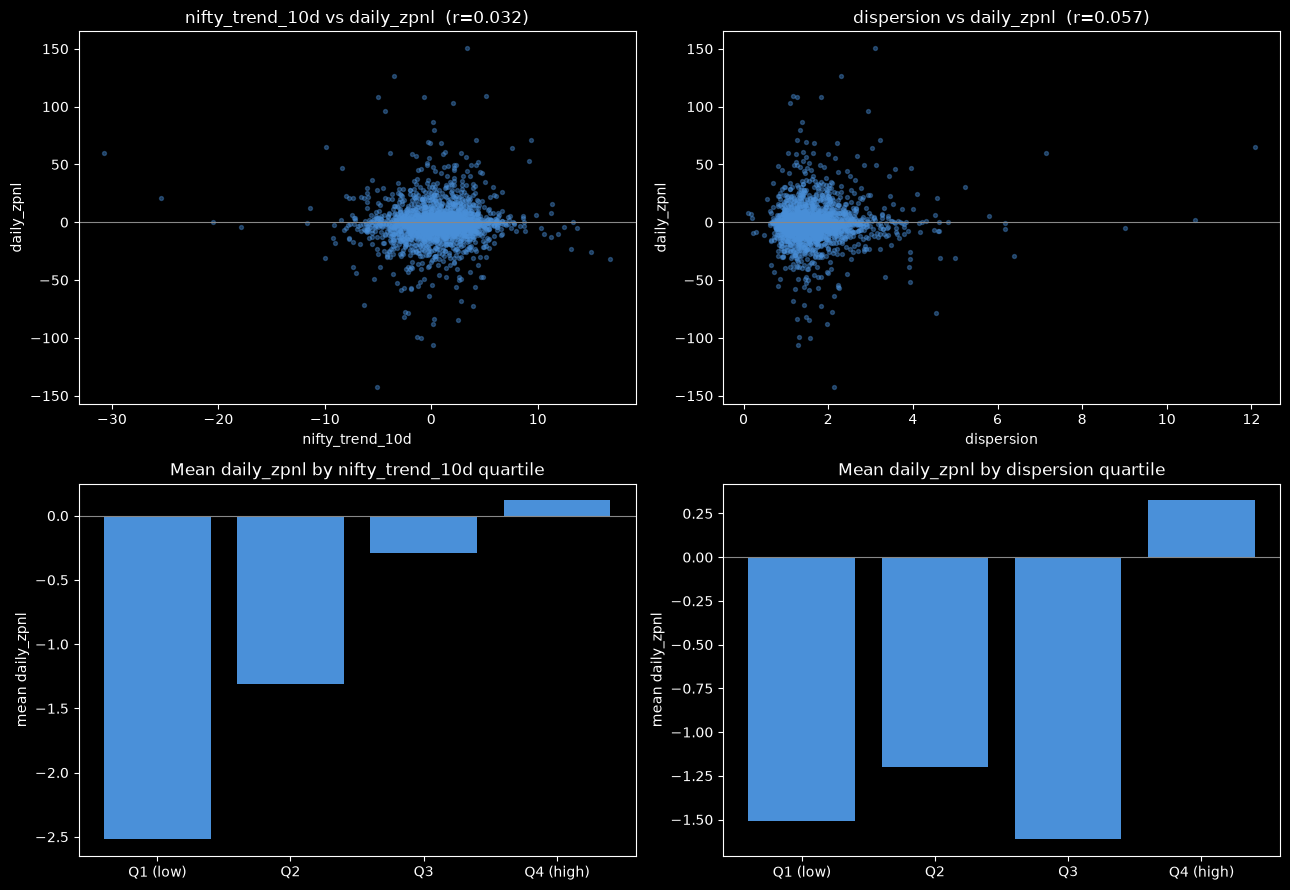

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for col, f in enumerate(FEATURES):
    axes[0, col].scatter(daily[f], daily['daily_zpnl'], s=8, alpha=0.4, color='#4a90d9')
    axes[0, col].axhline(0, color='#888', linewidth=0.8)
    axes[0, col].set_xlabel(f); axes[0, col].set_ylabel('daily_zpnl')
    r_val = results_df[(results_df.feature == f) & (results_df.target == 'daily_zpnl')]['r'].iloc[0]
    axes[0, col].set_title(f'{f} vs daily_zpnl  (r={r_val:.3f})')

    daily[f'{f}_quartile'] = pd.qcut(daily[f], 4, labels=['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)'])
    bucket_means = daily.groupby(f'{f}_quartile', observed=True)['daily_zpnl'].mean()
    axes[1, col].bar(bucket_means.index.astype(str), bucket_means.values, color='#4a90d9')
    axes[1, col].axhline(0, color='#888', linewidth=0.8)
    axes[1, col].set_title(f'Mean daily_zpnl by {f} quartile')
    axes[1, col].set_ylabel('mean daily_zpnl')
plt.tight_layout()
plt.show()


## 6. Verdict

In [14]:
print('Screen results -- iid columns kept for before/after comparison; _circ columns are primary:')
print(results_df.to_string(index=False))
print()
passed_circ = results_df[results_df.clears_individual_95_circ]
print(f'Clears CIRCULAR-SHIFT individual 95th-pct ceiling: {len(passed_circ)} of {len(results_df)} pairs')
if len(passed_circ):
    print(passed_circ[['target','feature','r','clears_individual_99_circ','emp_p_individual_circ']].to_string(index=False))
print()
print('=== FINAL VERDICT (updated 2026-09-17: max-of-N widened to 12 candidates) ===')
print()
print('nifty_trend_10d: DEAD, three ways over. Fails every r/null-calibration ceiling (iid or')
print('circular, individual or combined, max-of-2 or max-of-N). Also dead on theory -- weak-form')
print('market efficiency argues directional/first-moment features carry ~zero information from')
print('past prices, and its high raw acf1 (0.88) is a mechanical artifact of the 10-day')
print('overlapping-window construction (verified: NIFTY single-day return acf1=-0.025, near zero')
print('as theory predicts), not genuine regime persistence.')
print()
print('dispersion: borderline-real at best, RULED OUT as a usable gate -- and weaker the more')
print('rigorously it is tested. Clears the pair-only circular-shift 95th (individual + combined),')
print('but NOT 99th under any test. Widening the combined-null scope to max-of-N (section 3c,')
print('N=12 as of 2026-09-17, correcting for how many candidates were actually available to be')
print('picked from) AND doing the null properly (circular-shift, not iid): dispersion does NOT')
print('clear even the 95th-pct ceiling (real r=0.0575 vs circular ceil95=0.0629). The iid max-of-N')
print('check makes it look like it still passes (ceil95=0.0573) -- another instance of the iid-')
print('too-lenient pattern from 2b, now compounding with the widened scope. Under the single most')
print('rigorous test available (circular-shift + max-of-N), dispersion does not survive at all.')
print()
print('Two genuinely new candidates surfaced from the widened check, both comparable in size to')
print('dispersion, both completely unscreened beyond this raw r (no individual null-calibration,')
print('theory check, or OOS gate done yet): gap_pct (r=-0.0625, single strongest of all 12) and,')
print('added 2026-09-17, india_vix_level (r=+0.0519) and volume_surge (r=-0.0506) -- both landed')
print('right behind dispersion in the full ranking, ahead of nifty_trend_10d. india_vix_level in')
print('particular has strong a priori theoretical grounding (implied-vol "fear gauge", the most')
print('canonical regime indicator in finance, forward-looking unlike realized-vol/dispersion) --')
print('worth prioritizing for the next round of proper screening.')
print()
print('Decisive real-world test: `54c_oos_dispersion_gate.py` (chronological 70/30 split, cutoff')
print('chosen on TRAIN only) shows the concrete deployable form of the dispersion signal -- a')
print('lagged-dispersion Q5 threshold gate -- does NOT survive out of sample either. TRAIN\'s own')
print('best bucket is Q4 (ZPF 1.157), not Q5 (0.994, flat); TEST period has every quintile under')
print('1.0, with Q5 (highest dispersion) one of the WORST buckets (0.813) -- a full reversal.')
print()
print('NET VERDICT: dispersion fails the fully-rigorous statistical test AND fails the real-world')
print('OOS deployment test. RULED OUT for a 54d build off this pair. Next candidates to screen')
print('properly (own null-calibration + theory check + OOS gate, same rigor as dispersion got):')
print('gap_pct, india_vix_level, volume_surge -- in roughly that priority order given raw |r| and')
print('theoretical grounding.')
print()
print('54c.4 interaction/XOR check (below, section 7): run anyway for the completeness/learning')
print('value, despite both features already being individually dead -- that is exactly the')
print('scenario the check exists to catch (see design spec).')


Screen results -- iid columns kept for before/after comparison; _circ columns are primary:
        target         feature      r  clears_individual_95_iid  clears_individual_99_iid  emp_p_individual_iid  clears_combined_95_iid  emp_p_combined_iid  clears_individual_95_circ  clears_individual_99_circ  emp_p_individual_circ  clears_combined_95_circ  emp_p_combined_circ  textbook_p
    daily_zpnl nifty_trend_10d 0.0320                     False                     False                0.1078                   False              0.2058                      False                      False                 0.1480                    False               0.2782    0.110799
    daily_zpnl      dispersion 0.0565                      True                      True                0.0058                    True              0.0130                       True                      False                 0.0181                     True               0.0342    0.004798
profitable_day nifty_trend_10d 0.030

## 7. 54c.4 — Interaction / XOR check (nifty_trend_10d x dispersion)

Per the design spec: run this even though `nifty_trend_10d` fails alone — that's
exactly the scenario this check exists to catch (two features individually weak/null
by Pearson r can still jointly carry real information, since r is a linear-only
diagnostic and structurally blind to interaction-type/XOR relationships). One-time
exception for this notebook: computed against **both** iid and circular-shift nulls,
per Saurav's call — going forward, only circular-shift gets trusted/plotted.

**Escalation rule (design spec §4)**: a combined AND-rule must clear the noise ceiling
by more than either single feature does alone, or it's just an extra parameter for
noise to hide behind — not preferred over the single-feature dispersion result just
for looking interesting.

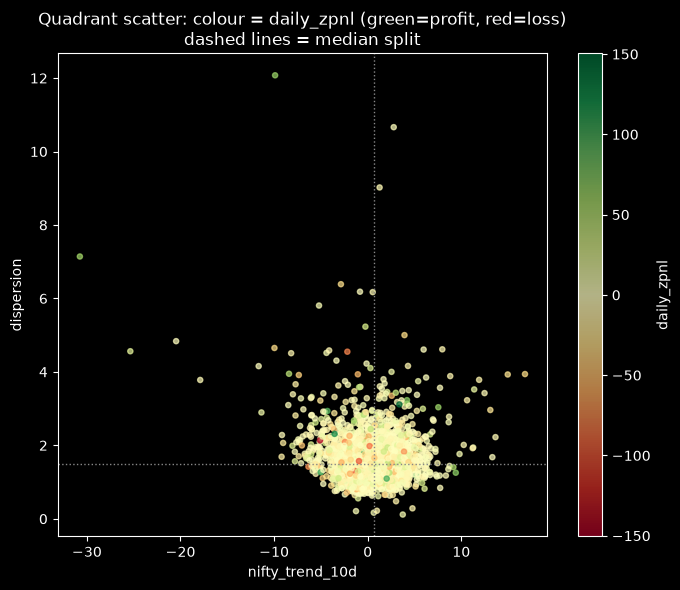

In [15]:
# 2D scatter, colored by outcome -- the #52 quadrant-scatter recipe.
# zpnl as a continuous colour gradient (design spec: this is the target the interaction
# plot colours by, since zpnl is the leading target for this variant).
fig, ax = plt.subplots(1, 1, figsize=(7, 6))
sc = ax.scatter(daily['nifty_trend_10d'], daily['dispersion'], c=daily['daily_zpnl'],
                 cmap='RdYlGn', vmin=-daily['daily_zpnl'].abs().max(), vmax=daily['daily_zpnl'].abs().max(),
                 s=14, alpha=0.7)
ax.axvline(daily['nifty_trend_10d'].median(), color='#888', linestyle=':', linewidth=1)
ax.axhline(daily['dispersion'].median(), color='#888', linewidth=1, linestyle=':')
ax.set_xlabel('nifty_trend_10d'); ax.set_ylabel('dispersion')
ax.set_title('Quadrant scatter: colour = daily_zpnl (green=profit, red=loss)\ndashed lines = median split')
plt.colorbar(sc, ax=ax, label='daily_zpnl')
plt.tight_layout()
plt.show()


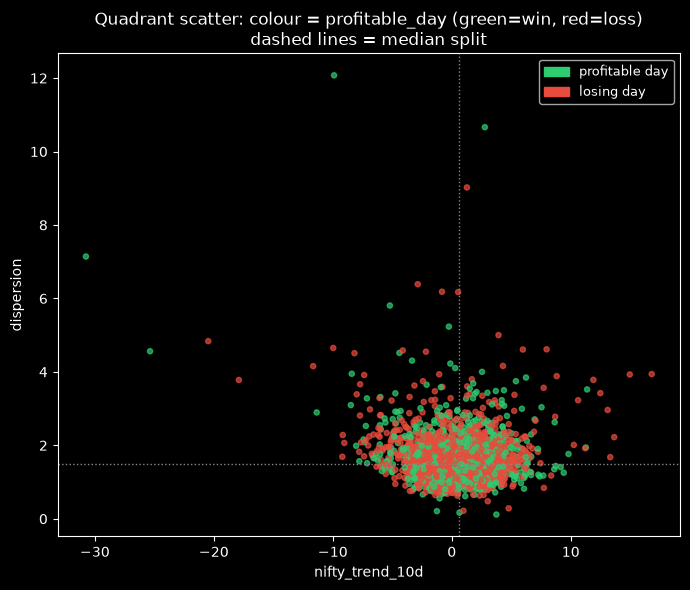

In [16]:
# Second panel: same scatter, coloured by the BINARY target (profitable_day) instead of
# the continuous gradient -- per the original design intro's plan ("zpnl as a colour
# gradient, win/loss as two colours"), never built until now. Sharper contrast, no
# washing-out near zero, at the cost of losing magnitude information -- the right tool
# specifically for eye-testing the profitable_day target.
fig, ax = plt.subplots(1, 1, figsize=(7, 6))
colors = daily['profitable_day'].map({1: '#2ecc71', 0: '#e74c3c'})
ax.scatter(daily['nifty_trend_10d'], daily['dispersion'], c=colors, s=14, alpha=0.7)
ax.axvline(daily['nifty_trend_10d'].median(), color='#888', linestyle=':', linewidth=1)
ax.axhline(daily['dispersion'].median(), color='#888', linewidth=1, linestyle=':')
ax.set_xlabel('nifty_trend_10d'); ax.set_ylabel('dispersion')
ax.set_title('Quadrant scatter: colour = profitable_day (green=win, red=loss)\ndashed lines = median split')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#2ecc71', label='profitable day'), Patch(color='#e74c3c', label='losing day')],
          loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()


In [17]:
# Quadrant table: median-split both features (no optimization/data-mining -- fixed,
# non-tuned split points), look for a genuine interaction signature (a quadrant that
# beats what either single-feature marginal would predict).
trend_med = daily['nifty_trend_10d'].median()
disp_med = daily['dispersion'].median()
daily['q_trend'] = np.where(daily['nifty_trend_10d'] > trend_med, 'trend_high', 'trend_low')
daily['q_disp'] = np.where(daily['dispersion'] > disp_med, 'disp_high', 'disp_low')

def zpf(z):
    pos = z[z > 0].sum(); neg = z[z < 0].sum()
    return pos / abs(neg) if neg != 0 else np.nan

quad = daily.groupby(['q_trend', 'q_disp']).agg(
    n_days=('daily_zpnl', 'size'),
    mean_zpnl=('daily_zpnl', 'mean'),
    net_zpnl=('daily_zpnl', 'sum'),
).reset_index()
print('Quadrant table (median-split, no tuning):')
print(quad.to_string(index=False))


Quadrant table (median-split, no tuning):
   q_trend    q_disp  n_days  mean_zpnl   net_zpnl
trend_high disp_high     612  -0.244766  -149.7969
trend_high  disp_low     632   0.069507    43.9287
 trend_low disp_high     632  -1.029710  -650.7769
 trend_low  disp_low     612  -2.824144 -1728.3760


In [18]:
# The combined rule itself: plain AND of two thresholds (median split), per complexity
# cap -- no fitted regression/logistic combination. Test whether ITS r beats both
# single-feature r's, under both null types (one-time exception, this notebook only).
combined_flag = ((daily['nifty_trend_10d'] > trend_med) & (daily['dispersion'] > disp_med)).astype(int)

results_xor = []
for target_col in ['daily_zpnl', 'profitable_day']:
    y = daily[target_col].values.astype(float)
    r_combined = np.corrcoef(combined_flag.values, y)[0, 1]

    # iid null for this specific derived binary feature
    n_shuf = N_SHUFFLES
    null_iid = np.empty(n_shuf)
    y_shuf = y.copy()
    for i in range(n_shuf):
        np.random.shuffle(y_shuf)
        null_iid[i] = np.corrcoef(combined_flag.values, y_shuf)[0, 1]
    ceil95_iid, ceil99_iid = np.percentile(np.abs(null_iid), [95, 99])

    # circular-shift null (exhaustive)
    n = len(y)
    null_circ = np.empty(n - 1)
    for shift in range(1, n):
        null_circ[shift - 1] = np.corrcoef(combined_flag.values, np.roll(y, shift))[0, 1]
    ceil95_circ, ceil99_circ = np.percentile(np.abs(null_circ), [95, 99])

    r_trend = np.corrcoef(daily['nifty_trend_10d'], y)[0, 1]
    r_disp = np.corrcoef(daily['dispersion'], y)[0, 1]

    results_xor.append(dict(
        target=target_col, r_combined=round(r_combined, 4),
        r_trend_alone=round(r_trend, 4), r_dispersion_alone=round(r_disp, 4),
        beats_both_singles=abs(r_combined) > max(abs(r_trend), abs(r_disp)),
        clears95_iid=abs(r_combined) > ceil95_iid, clears99_iid=abs(r_combined) > ceil99_iid,
        clears95_circ=abs(r_combined) > ceil95_circ, clears99_circ=abs(r_combined) > ceil99_circ,
    ))

results_xor_df = pd.DataFrame(results_xor)
results_xor_df


,target,r_combined,r_trend_alone,r_dispersion_alone,beats_both_singles,clears95_iid,clears99_iid,clears95_circ,clears99_circ
0,daily_zpnl,0.0258,0.0320,0.0565,False,False,False,False,False
1,profitable_day,0.0244,0.0308,0.0261,False,False,False,False,False


### 7b. XOR check verdict

In [19]:
print(results_xor_df.to_string(index=False))
print()
any_pass = results_xor_df[results_xor_df.clears95_circ & results_xor_df.beats_both_singles]
if len(any_pass):
    print('COMBINED RULE SURVIVES the escalation bar (clears circular-shift 95th AND beats both')
    print('single features) -- would be worth a closer look despite trend failing alone.')
else:
    print('COMBINED RULE DOES NOT SURVIVE: either it fails to clear the circular-shift ceiling,')
    print('or it does not beat dispersion alone even where it clears -- confirms the escalation')
    print('rule working as designed (not preferring a fancier-looking rule without genuine added')
    print('signal). Consistent with the quadrant table above showing no quadrant meaningfully')
    print('outperforming dispersion\'s own marginal split. XOR/interaction theory itself remains')
    print('valid in general -- this specific pair (one dead feature + one already-ruled-out one)')
    print('was just not a promising candidate for it, exactly as flagged before running this.')
print()
print('54c series closed out for this pair (nifty_trend_10d, dispersion): both ruled out, alone')
print('and combined. Next candidates: gap_pct (needs its own null-calibration + theory check +')
print('OOS gate), then volume_surge (definition locked, not yet built).')


        target  r_combined  r_trend_alone  r_dispersion_alone  beats_both_singles  clears95_iid  clears99_iid  clears95_circ  clears99_circ
    daily_zpnl      0.0258         0.0320              0.0565               False         False         False          False          False
profitable_day      0.0244         0.0308              0.0261               False         False         False          False          False

COMBINED RULE DOES NOT SURVIVE: either it fails to clear the circular-shift ceiling,
or it does not beat dispersion alone even where it clears -- confirms the escalation
rule working as designed (not preferring a fancier-looking rule without genuine added
signal). Consistent with the quadrant table above showing no quadrant meaningfully
outperforming dispersion's own marginal split. XOR/interaction theory itself remains
valid in general -- this specific pair (one dead feature + one already-ruled-out one)
was just not a promising candidate for it, exactly as flagged before 